In [1]:
"""
Cell 1: Environment Setup & Reproducibility
Project: NanoReason (Qwen2.5-3B-Instruct)
Target: Q1/Q2 Journals & Top-Tier AI Challenges

- Chức năng: 
  1. Tối ưu hóa phân bổ bộ nhớ CUDA cho Kaggle T4x2.
  2. Thiết lập Seed cố định để đảm bảo tính lặp lại (Reproducibility) tuyệt đối.
  3. Kiểm tra và log thông số phần cứng để lưu vào bài báo khoa học.
"""

import os
import torch
import random
import numpy as np

# ============================================================================
# 1. AGGRESSIVE MEMORY OPTIMIZATION FOR KAGGLE T4x2
# ============================================================================
# Chống phân mảnh bộ nhớ (Memory Fragmentation) - Cực kỳ quan trọng cho mô hình 3B
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# Tối ưu hóa đa luồng cho Tokenizer
os.environ["TOKENIZERS_PARALLELISM"] = "true"

# ============================================================================
# 2. STRICT REPRODUCIBILITY (Bắt buộc cho Research Q1/Q2)
# ============================================================================
def set_seed(seed=42):
    """Cố định toàn bộ các hạt giống ngẫu nhiên để kết quả không bị xê dịch."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Đồng bộ seed trên cả 2 GPU T4
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ============================================================================
# 3. HARDWARE & ENVIRONMENT TELEMETRY
# ============================================================================
print("=" * 80)
print("🚀 NANO-REASON: ENVIRONMENT & HARDWARE INITIALIZATION")
print("=" * 80)
print(f"PyTorch Version: {torch.__version__}")

if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"CUDA Available: True")
    print(f"Number of GPUs detected: {num_gpus}")
    
    total_vram = 0
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_mem = torch.cuda.get_device_properties(i).total_memory / (1024**3)
        total_vram += gpu_mem
        print(f"  GPU {i}: {gpu_name} ({gpu_mem:.2f} GB VRAM)")
        
    print(f"Total Combined VRAM: {total_vram:.2f} GB")
else:
    print("❌ CRITICAL: No GPU found. Please check Kaggle Accelerator settings!")

print("-" * 80)
print("✅ Seed 42 locked for absolute reproducibility.")
print("✅ PyTorch CUDA Allocator optimized for expandable segments.")
print("=" * 80)

🚀 NANO-REASON: ENVIRONMENT & HARDWARE INITIALIZATION
PyTorch Version: 2.9.0+cu126
CUDA Available: True
Number of GPUs detected: 2
  GPU 0: Tesla T4 (14.56 GB VRAM)
  GPU 1: Tesla T4 (14.56 GB VRAM)
Total Combined VRAM: 29.13 GB
--------------------------------------------------------------------------------
✅ Seed 42 locked for absolute reproducibility.
✅ PyTorch CUDA Allocator optimized for expandable segments.


In [2]:
"""
Cell 2: Cài đặt thư viện chuyên sâu
"""
# Tắt cảnh báo để giữ log sạch sẽ
import warnings
warnings.filterwarnings("ignore")

!pip install -q -U transformers==4.38.0
!pip install -q -U peft==0.9.0
!pip install -q -U accelerate==0.27.0
!pip install -q -U bitsandbytes==0.42.0
!pip install -q -U datasets==2.17.0
!pip install -q -U sentencepiece 

print("✅ Packages installed successfully!")


"""
Cell 3: Import thư viện & Setup Đồ họa
"""
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass
from enum import Enum, auto
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Style đồ thị chuẩn Research Paper
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 300

print("✅ Libraries imported!")


"""
Cell 4: Kiến trúc Logic (Reasoning Step)
"""
class StepType(Enum):
    UNDERSTAND = 0
    PLAN = 1
    EXECUTE = 2
    VERIFY = 3

    @property
    def tag(self) -> str:
        """Thẻ đánh dấu chuẩn dùng trong prompt"""
        return f"#### {self.name} ####"

@dataclass
class ReasoningStep:
    step_type: StepType
    content: str

@dataclass
class ReasoningChain:
    question: str
    steps: Dict[StepType, ReasoningStep]
    ground_truth: str
    is_correct: bool
    
    def get_full_text(self) -> str:
        """Tạo chuỗi văn bản hoàn chỉnh để đưa vào mô hình"""
        text = f"Question: {self.question}\n\nSolution:\n"
        # Duyệt theo thứ tự logic bắt buộc
        for stype in [StepType.UNDERSTAND, StepType.PLAN, StepType.EXECUTE, StepType.VERIFY]:
            text += f"{stype.tag}\n{self.steps[stype].content}\n\n"
        
        # Gắn chặt Ground Truth vào ngay sau Verify
        text += f"Final Answer: {self.ground_truth}"
        return text

print("✅ Core structures defined!")

"""
Cell 5: Data Paths Detection (Full Version)
"""
DATA_DIR = Path("/kaggle/input/datasets/trinhduc041/nckh-processed-data")

print("Available files:")
for f in DATA_DIR.glob("*.jsonl"):
    print(f"  📁 {f.name} ({(f.stat().st_size / 1e6):.2f} MB)")

# Khai báo đầy đủ các biến đường dẫn
GSM8K_TRAIN_PATH = DATA_DIR / "gsm8k_train_processed.jsonl"
GSM8K_TEST_PATH = DATA_DIR / "gsm8k_test_processed.jsonl"
MATH_TRAIN_PATH = DATA_DIR / "math_train_processed.jsonl"
MATH_TEST_PATH = DATA_DIR / "math_test_processed.jsonl"
VNHSGE_PATH = DATA_DIR / "vnhsge_processed.jsonl"

print(f"\n✅ All dataset paths configured successfully!")


"""
Cell 6: StepAwareDataset (The Ultimate Fast Version)
- Sử dụng FastTokenizer để map Token-to-Step cực nhanh.
"""
class StepAwareDataset(Dataset):
    def __init__(
        self,
        data_path: Path,
        tokenizer,
        max_length: int = 1024,
        filter_correct_only: bool = True
    ):
        self.data_path = data_path
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.filter_correct_only = filter_correct_only
        
        # Cấu hình Tokenizer bắt buộc cho Qwen
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.tokenizer.padding_side = "right" # Phải luôn là right padding khi Train CausalLM
        
        self.chains = self._load_data()
        print(f"✅ Ready! Dataset size: {len(self.chains)}")

    def _load_data(self) -> List[ReasoningChain]:
        chains = []
        print(f"\n📂 Loading and validating {self.data_path.name}...")
        
        with open(self.data_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                data = json.loads(line)
                
                if self.filter_correct_only and not data.get('is_correct', True):
                    continue
                    
                if 'cot_4steps' not in data:
                    continue
                    
                cot = data['cot_4steps']
                if not all(k in cot for k in ['understand', 'plan', 'execute', 'verify']):
                    continue
                    
                chain = ReasoningChain(
                    question=data.get('question', ''),
                    steps={
                        StepType.UNDERSTAND: ReasoningStep(StepType.UNDERSTAND, cot['understand']),
                        StepType.PLAN: ReasoningStep(StepType.PLAN, cot['plan']),
                        StepType.EXECUTE: ReasoningStep(StepType.EXECUTE, cot['execute']),
                        StepType.VERIFY: ReasoningStep(StepType.VERIFY, cot['verify'])
                    },
                    ground_truth=data.get('ground_truth', ''),
                    is_correct=data.get('is_correct', True)
                )
                chains.append(chain)
                
        return chains

    def __len__(self) -> int:
        return len(self.chains)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        chain = self.chains[idx]
        
        # ==========================================
        # KỊCH BẢN 3: FLAT TEXT (KHÔNG DÙNG TAG VÀ OFFSET_MAPPING)
        # ==========================================
        
        # 1. Nối văn bản thô, cố tình BỎ QUA các thẻ tag (stype.tag)
        flat_text = f"Question: {chain.question}\n\nSolution:\n"
        for stype in [StepType.UNDERSTAND, StepType.PLAN, StepType.EXECUTE, StepType.VERIFY]:
            # Chỉ lấy nội dung (content), không lấy thẻ (tag)
            flat_text += f"{chain.steps[stype].content}\n" 
            
        flat_text += f"\nFinal Answer: {chain.ground_truth}"
        
        # 2. Tokenize văn bản phẳng (Không cần return_offsets_mapping nữa cho nhẹ máy)
        encoding = self.tokenizer(
            flat_text,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        # 3. ÉP TOÀN BỘ STEP_LABELS VỀ 0
        # Vì đây là một khối văn bản liền mạch, ta coi tất cả là Step 0
        step_labels = torch.zeros_like(input_ids)
            
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'step_labels': step_labels
        }

print("✅ Optimized StepAwareDataset defined!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 111.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.7/279.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.6/536.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 12.8 

Loading tokenizer: Qwen/Qwen2.5-3B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


✅ Tokenizer loaded successfully!
  Vocab size: 151,665
  Pad token: <|endoftext|>
  EOS token: <|im_end|>
Creating datasets...

1️⃣  GSM8K TRAIN:

📂 Loading and validating gsm8k_train_processed.jsonl...
✅ Ready! Dataset size: 7431

2️⃣  GSM8K TEST:

📂 Loading and validating gsm8k_test_processed.jsonl...
✅ Ready! Dataset size: 1309

3️⃣  MATH TRAIN:

📂 Loading and validating math_train_processed.jsonl...
✅ Ready! Dataset size: 10388

FINAL DATASET SUMMARY
  GSM8K Train:  7,431 samples
  MATH Train:   10,388 samples
  ──────────────────────────────────
  TOTAL TRAIN:  17,819 samples
✅ Datasets ready for training.
SAMPLE TENSOR INSPECTION

1. Tensor Shapes:
   input_ids: torch.Size([1024])
   attention_mask: torch.Size([1024])
   step_labels: torch.Size([1024])

2. Step Label Distribution:
   UNDERSTAND (ID 0): 1024 tokens
   PLAN (ID 1): 0 tokens
   EXECUTE (ID 2): 0 tokens
   VERIFY (ID 3): 0 tokens

3. Decoded Text Snippet:
Question: Natalia sold clips to 48 of her friends in April, an

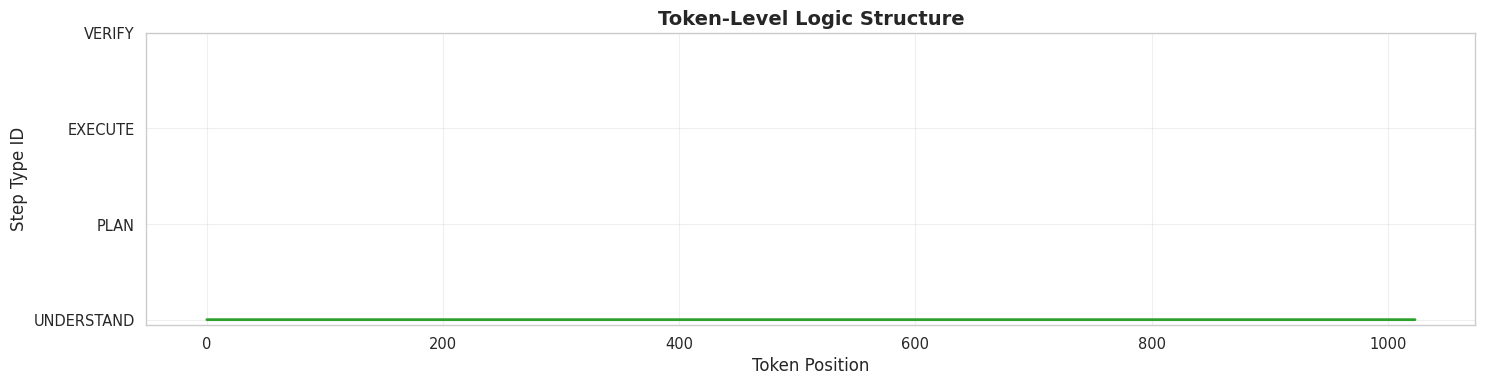

✅ HierarchicalStepLoss (CAUSAL SHIFT INTEGRATED) defined!


In [3]:
"""
Cell 7: Load Qwen2.5 Tokenizer

Nâng cấp lên Qwen2.5-3B-Instruct:
- Tăng cường khả năng lập luận toán học phức tạp.
- Hỗ trợ tiếng Việt xuất sắc.
"""

# 🚀 Nâng cấp Model lên 3B
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    use_fast=True
)

# Cấu hình Padding Token (Bắt buộc cho Qwen)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"✅ Tokenizer loaded successfully!")
print(f"  Vocab size: {len(tokenizer):,}")
print(f"  Pad token: {tokenizer.pad_token}")
print(f"  EOS token: {tokenizer.eos_token}")

"""
Cell 8: Khởi tạo Datasets
"""

print("Creating datasets...")
print("=" * 70)

# Khởi tạo các tập dữ liệu. Dùng max_length=1024 để tối ưu VRAM và Thời gian
MAX_LEN = 1024

print("\n1️⃣  GSM8K TRAIN:")
gsm8k_train_dataset = StepAwareDataset(
    data_path=GSM8K_TRAIN_PATH,
    tokenizer=tokenizer,
    max_length=MAX_LEN,
    filter_correct_only=True
)

print("\n2️⃣  GSM8K TEST:")
# Dùng try-except để nếu file Kaggle không tồn tại thì cũng không bị Crash
try:
    gsm8k_test_dataset = StepAwareDataset(
        data_path=GSM8K_TEST_PATH,
        tokenizer=tokenizer,
        max_length=MAX_LEN,
        filter_correct_only=True
    )
except FileNotFoundError:
    print("⚠️ GSM8K Test file not found, skipping...")
    gsm8k_test_dataset = []

print("\n3️⃣  MATH TRAIN:")
try:
    math_train_dataset = StepAwareDataset(
        data_path=MATH_TRAIN_PATH,
        tokenizer=tokenizer,
        max_length=MAX_LEN,
        filter_correct_only=True
    )
except FileNotFoundError:
    print("⚠️ MATH Train file not found, skipping...")
    math_train_dataset = []

print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)
print(f"  GSM8K Train:  {len(gsm8k_train_dataset):,} samples")
if math_train_dataset:
    print(f"  MATH Train:   {len(math_train_dataset):,} samples")
print(f"  ──────────────────────────────────")
total_train = len(gsm8k_train_dataset) + (len(math_train_dataset) if math_train_dataset else 0)
print(f"  TOTAL TRAIN:  {total_train:,} samples")
print("=" * 70)

if total_train == 0:
    print("❌ CRITICAL ERROR: All training datasets are empty!")
else:
    print("✅ Datasets ready for training.")
"""
Cell 9: Data Inspection (Kiểm tra chất lượng Tensor)
"""

print("SAMPLE TENSOR INSPECTION")
print("=" * 50)

if total_train > 0:
    sample = gsm8k_train_dataset[0]
    
    print(f"\n1. Tensor Shapes:")
    print(f"   input_ids: {sample['input_ids'].shape}")
    print(f"   attention_mask: {sample['attention_mask'].shape}")
    print(f"   step_labels: {sample['step_labels'].shape}")
    
    print(f"\n2. Step Label Distribution:")
    for step_id in range(4):
        count = (sample['step_labels'] == step_id).sum().item()
        step_name = ['UNDERSTAND', 'PLAN', 'EXECUTE', 'VERIFY'][step_id]
        print(f"   {step_name} (ID {step_id}): {count} tokens")
    
    print(f"\n3. Decoded Text Snippet:")
    decoded_text = tokenizer.decode(sample['input_ids'][:100], skip_special_tokens=True)
    print(decoded_text.replace('\n', ' \\n ') + " ...")
    
    print("=" * 50)


"""
Cell 10: Trực quan hóa Phân phối Step Labels
"""

if total_train > 0:
    sample = gsm8k_train_dataset[0]
    
    # Đảm bảo tensor được đưa về CPU trước khi vẽ
    step_labels_np = sample['step_labels'].cpu().numpy()
    
    plt.figure(figsize=(15, 4))
    plt.plot(step_labels_np, drawstyle='steps-post', linewidth=2, color='#2ca02c')
    plt.ylabel('Step Type ID', fontsize=12)
    plt.xlabel('Token Position', fontsize=12)
    plt.title('Token-Level Logic Structure', fontsize=14, fontweight='bold')
    plt.yticks([0, 1, 2, 3], ['UNDERSTAND', 'PLAN', 'EXECUTE', 'VERIFY'])
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


"""
Cell 11: Hierarchical Loss (VỚI CÚ FIX CAUSAL SHIFT LỊCH SỬ)
"""

class HierarchicalStepLoss(nn.Module):
    """
    Hàm Loss đã được tinh chỉnh với Causal Shift.
    Ngăn chặn tuyệt đối hiện tượng "học vẹt" (dùng input để dự đoán lại chính input).
    """
    
    def __init__(
        self,
        alpha: float = 0.2,
        beta: float = 0.3,
        gamma: float = 0.3,
        delta: float = 0.2,
        epsilon: float = 0.1,
        label_smoothing: float = 0.1
    ):
        super().__init__()
        self.weights = {0: alpha, 1: beta, 2: gamma, 3: delta}
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
    
    def forward(
        self,
        logits: torch.Tensor,
        labels: torch.Tensor,
        step_labels: torch.Tensor,
        attention_mask: torch.Tensor
    ) -> Dict[str, torch.Tensor]:
        
        # 🔥 THE MOTHER OF ALL BUGS FIXED HERE: CAUSAL SHIFT 🔥
        # Logits ở vị trí t sẽ dùng để dự đoán Labels ở vị trí t+1
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        shift_step_labels = step_labels[..., 1:].contiguous()
        shift_attention_mask = attention_mask[..., 1:].contiguous()
        
        step_losses = {}
        total_loss = torch.tensor(0.0, device=logits.device)
        
        # Per-step losses (Tính toán trên dữ liệu đã Shift)
        for step_id in range(4):
            step_mask = (shift_step_labels == step_id).float() * shift_attention_mask
            
            if step_mask.sum() > 0:
                step_loss = self._compute_step_loss(shift_logits, shift_labels, step_mask)
                weighted_loss = self.weights[step_id] * step_loss
                
                step_losses[f'step_{step_id}_loss'] = step_loss.item() 
                total_loss = total_loss + weighted_loss  
            else:
                step_losses[f'step_{step_id}_loss'] = 0.0
        
        # Transition penalty (Vẫn giữ nguyên nguyên tắc phạt khi model "nhảy cóc" các bước)
        transition_loss = self._compute_transition_penalty(shift_step_labels, shift_attention_mask)
        step_losses['transition_loss'] = transition_loss.item() 
        
        total_loss = total_loss + self.epsilon * transition_loss 
        step_losses['total_loss'] = total_loss
        
        return step_losses
    
    def _compute_step_loss(self, logits, labels, mask):
        logits_flat = logits.view(-1, logits.size(-1))
        labels_flat = labels.view(-1)
        mask_flat = mask.view(-1)
        
        loss = F.cross_entropy(
            logits_flat, labels_flat, reduction='none', label_smoothing=self.label_smoothing
        )
        return (loss * mask_flat).sum() / (mask_flat.sum() + 1e-8)
    
    def _compute_transition_penalty(self, step_labels, attention_mask):
        step_diff = step_labels[:, 1:] - step_labels[:, :-1]
        mask = attention_mask[:, 1:] * attention_mask[:, :-1]
        
        backward_penalty = (step_diff < 0).float() * mask
        skip_penalty = (step_diff > 1).float() * mask
        
        return (backward_penalty + skip_penalty).sum() / (mask.sum() + 1e-8)

print("✅ HierarchicalStepLoss (CAUSAL SHIFT INTEGRATED) defined!")

CAUSAL SHIFT LOSS TEST
step_0_loss         : 12.4298
step_1_loss         : 12.4676
step_2_loss         : 12.2689
step_3_loss         : 12.3011
transition_loss     : 0.0000
total_loss          : 12.3671
✅ Loss function with Causal Shift works correctly!
✅ HierarchicalStepSupervisor defined
Loading QWEN 2.5 3B with Aggressive Memory Optimizations...
Loading Base Model for Inspection: Qwen/Qwen2.5-3B-Instruct


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Model loaded on cuda:0

GPU VRAM Allocation After Model Load:
  GPU 0: 3.70 GB
  GPU 1: 3.08 GB
Re-creating datasets for Dataloader...

📂 Loading and validating gsm8k_train_processed.jsonl...
✅ Ready! Dataset size: 7431

📂 Loading and validating math_train_processed.jsonl...
✅ Ready! Dataset size: 10388

✅ Safe DataLoaders Ready:
   Batch Size: 1 | Sequence Length: 1024
   Total Train Batches: 7431
🔥 FORWARD PASS INFERENCE TEST (QWEN 3B)


2026-03-06 13:24:06.748766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772803446.953090      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772803447.012572      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772803447.480322      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772803447.480354      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772803447.480357      23 computation_placer.cc:177] computation placer alr

✅ Safe Forward pass successful! No OOM!


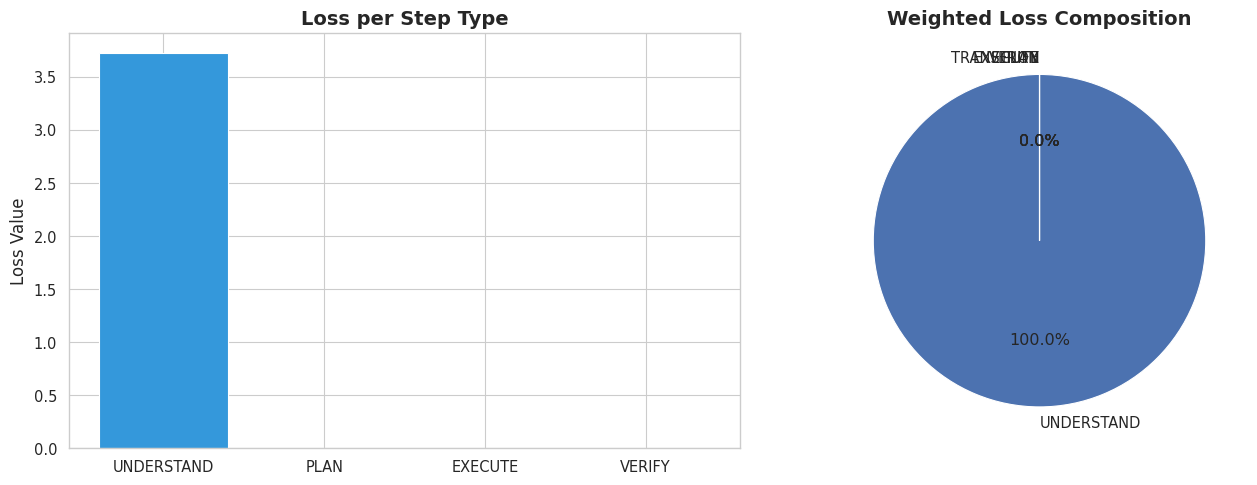

In [4]:
"""
Cell 12: Test Causal Shift Loss Function với Dummy Data
Kiểm tra tính an toàn và khả năng flow gradient.
"""
# Create dummy batch
batch_size, seq_len, vocab_size = 2, 128, len(tokenizer)

dummy_logits = torch.randn(batch_size, seq_len, vocab_size)
dummy_labels = torch.randint(0, vocab_size, (batch_size, seq_len))
dummy_attention = torch.ones(batch_size, seq_len)

dummy_steps = torch.zeros(batch_size, seq_len, dtype=torch.long)
dummy_steps[:, :32] = 0
dummy_steps[:, 32:64] = 1
dummy_steps[:, 64:96] = 2
dummy_steps[:, 96:] = 3

loss_fn = HierarchicalStepLoss()
losses = loss_fn(dummy_logits, dummy_labels, dummy_steps, dummy_attention)

print("CAUSAL SHIFT LOSS TEST")
print("=" * 50)
for key, value in losses.items():
    if isinstance(value, torch.Tensor):
        print(f"{key:20s}: {value.item():.4f}")
    else:
        print(f"{key:20s}: {value:.4f}")
print("✅ Loss function with Causal Shift works correctly!")


"""
Cell 13: HierarchicalStepSupervisor (WITH CAUSAL SHIFT ACCURACY)
Wrapper Model dùng để test Forward Pass trước khi gắn LoRA.
"""
class HierarchicalStepSupervisor(nn.Module):
    def __init__(
        self,
        base_model_name: str = "Qwen/Qwen2.5-3B-Instruct",
        loss_weights: Optional[Dict] = None,
        use_flash_attention: bool = False
    ):
        super().__init__()
        print(f"Loading Base Model for Inspection: {base_model_name}")
        
        self.base_model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            torch_dtype=torch.float16, # Bắt buộc cho T4 + AMP
            trust_remote_code=True,
            use_flash_attention_2=use_flash_attention,
            device_map="auto" 
        )
        
        if loss_weights is None:
            loss_weights = {'alpha': 0.2, 'beta': 0.3, 'gamma': 0.3, 'delta': 0.2, 'epsilon': 0.1}
        self.loss_fn = HierarchicalStepLoss(**loss_weights)
        print(f"✅ Model loaded on {self.base_model.device}")
    
    def forward(self, input_ids, attention_mask, step_labels, labels=None):
        outputs = self.base_model(
            input_ids=input_ids, attention_mask=attention_mask,
            labels=labels if labels is not None else input_ids, return_dict=True
        )
        logits = outputs.logits
        if labels is not None:
            losses = self.loss_fn(logits=logits, labels=labels, step_labels=step_labels, attention_mask=attention_mask)
            step_accs = self._compute_step_accuracies(logits, labels, step_labels, attention_mask)
            losses.update(step_accs)
        else:
            losses = {'total_loss': torch.tensor(0.0)}
        return {'logits': logits, **losses}
    
    def _compute_step_accuracies(self, logits, labels, step_labels, attention_mask):
        # 🔥 ĐÃ FIX CAUSAL SHIFT (Tránh Accuracy 0%)
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        shift_step_labels = step_labels[..., 1:].contiguous()
        shift_attention_mask = attention_mask[..., 1:].contiguous()
        
        predictions = shift_logits.argmax(dim=-1)
        accuracies = {}
        for step_id in range(4):
            step_mask = (shift_step_labels == step_id) * shift_attention_mask
            if step_mask.sum() > 0:
                correct = ((predictions == shift_labels) * step_mask).sum()
                accuracies[f'step_{step_id}_accuracy'] = (correct.float() / step_mask.sum()).item()
            else:
                accuracies[f'step_{step_id}_accuracy'] = 0.0
        return accuracies

print("✅ HierarchicalStepSupervisor defined")


"""
Cell 14: Load Qwen2.5-3B và Tối ưu bộ nhớ
"""
import gc

if 'supervisor' in locals(): del supervisor
torch.cuda.empty_cache()
gc.collect()

print("Loading QWEN 2.5 3B with Aggressive Memory Optimizations...")
supervisor = HierarchicalStepSupervisor(base_model_name=MODEL_NAME)

# 🛑 Bắt buộc bật để train được 3B trên 16GB VRAM
supervisor.base_model.gradient_checkpointing_enable()

print("\nGPU VRAM Allocation After Model Load:")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.2f} GB")


"""
Cell 15: Safe DataLoaders cho 3B Model trên Kaggle T4
"""
# TỐI ƯU CỰC HẠN CHO MÔ HÌNH 3 TỶ THAM SỐ
BATCH_SIZE = 1  
MAX_LENGTH = 1024 
NUM_WORKERS = 2

print("Re-creating datasets for Dataloader...")
gsm8k_train_dataset = StepAwareDataset(
    data_path=GSM8K_TRAIN_PATH, tokenizer=tokenizer, 
    max_length=MAX_LENGTH, filter_correct_only=True
)
math_train_dataset = StepAwareDataset(
    data_path=MATH_TRAIN_PATH, tokenizer=tokenizer, 
    max_length=MAX_LENGTH, filter_correct_only=True
)

train_loader = DataLoader(gsm8k_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\n✅ Safe DataLoaders Ready:")
print(f"   Batch Size: {BATCH_SIZE} | Sequence Length: {MAX_LENGTH}")
print(f"   Total Train Batches: {len(train_loader)}")


"""
Cell 16 & 17: Forward Pass Test & Visualization 
"""
torch.cuda.empty_cache()
batch = next(iter(train_loader))

# MASKING PADDING: Cấm Model tốn sức học Padding Token
input_ids = batch['input_ids'].cuda()
attention_mask = batch['attention_mask'].cuda()
step_labels = batch['step_labels'].cuda()

labels = input_ids.clone()
labels[attention_mask == 0] = -100 # Kỹ thuật then chốt 

print("🔥 FORWARD PASS INFERENCE TEST (QWEN 3B)")
print("=" * 50)
try:
    with torch.cuda.amp.autocast(dtype=torch.float16): # Giả lập môi trường AMP
        with torch.no_grad():
            outputs = supervisor(
                input_ids=input_ids, attention_mask=attention_mask,
                step_labels=step_labels, labels=labels
            )
            
    print(f"✅ Safe Forward pass successful! No OOM!")
    
    # Chuẩn bị dữ liệu vẽ biểu đồ
    step_losses = [outputs[f'step_{i}_loss'].item() if isinstance(outputs[f'step_{i}_loss'], torch.Tensor) else outputs[f'step_{i}_loss'] for i in range(4)]
    transition_loss = outputs['transition_loss'].item() if isinstance(outputs['transition_loss'], torch.Tensor) else outputs['transition_loss']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    step_names = ['UNDERSTAND', 'PLAN', 'EXECUTE', 'VERIFY']
    ax1.bar(step_names, step_losses, color=['#3498db', '#9b59b6', '#e74c3c', '#2ecc71'])
    ax1.set_ylabel('Loss Value', fontsize=12)
    ax1.set_title('Loss per Step Type', fontsize=14, fontweight='bold')
    
    weights = [0.2, 0.3, 0.3, 0.2]
    weighted_losses = [w * l for w, l in zip(weights, step_losses)]
    ax2.pie(weighted_losses + [0.1 * transition_loss], labels=step_names + ['TRANSITION'], autopct='%1.1f%%', startangle=90)
    ax2.set_title('Weighted Loss Composition', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

except RuntimeError as e:
    print(f"❌ TEST FAILED (OOM): {e}")

"""
 ADAPTIVE LORA RANK
=============================

Mục tiêu:
1. Xây dựng Problem Complexity Estimator
2. Implement Adaptive LoRA Rank mechanism
3. Integrate PEFT library
4. Test dynamic rank switching (4→8→16→32)

Timeline:
- Ngày 3: Complexity Estimator + Adaptive Rank Logic
- Ngày 4: PEFT Integration + Testing

Expected Output:
- LoRA modules with dynamic rank allocation
- Memory-efficient training setup
- Rank vs. accuracy benchmarks
"""


In [5]:
"""
Cell 3: Problem Complexity Estimator
Dùng để phân tích đặc tính dữ liệu (Data Analysis) cho bài báo Q1/Q2.
"""
import re
from typing import Dict, List

class ProblemComplexityEstimator:
    """Đánh giá độ khó của bài toán dựa trên các đặc trưng ngôn ngữ và toán học."""
    
    COMPLEX_KEYWORDS = {
        'derivative', 'integral', 'limit', 'polynomial', 'quadratic',
        'probability', 'permutation', 'matrix', 'vector', 'theorem'
    }
    
    def __init__(self):
        self.weights = {'length': 0.2, 'numbers': 0.3, 'operators': 0.2, 'keywords': 0.3}
    
    def estimate(self, question: str) -> Dict[str, float]:
        question = question.lower()
        
        # Normalize các features về khoảng [0, 1]
        length_score = min(len(question) / 500, 1.0)
        
        numbers = re.findall(r'\d+\.?\d*', question)
        number_score = min(len(numbers) / 10, 1.0)
        
        operators = ['+', '-', '*', '/', '=', '>', '<', '≥', '≤', '^']
        operator_score = min(sum(question.count(op) for op in operators) / 10, 1.0)
        
        keyword_score = min(sum(1 for kw in self.COMPLEX_KEYWORDS if kw in question) / 3, 1.0)
        
        complexity_score = (
            self.weights['length'] * length_score +
            self.weights['numbers'] * number_score +
            self.weights['operators'] * operator_score +
            self.weights['keywords'] * keyword_score
        )
        
        return {
            'complexity_score': complexity_score,
            'question_length': len(question),
            'number_count': len(numbers),
            'keyword_count': int(keyword_score * 3)
        }

print("✅ ProblemComplexityEstimator defined for Data Analysis.")


"""
Cell 4: LoRA Configuration Manager
Thiết lập cấu hình LoRA tối ưu cho mô hình Qwen2.5-3B
"""
from peft import LoraConfig, TaskType

class LoRAConfigManager:
    """Quản lý cấu hình LoRA chuẩn Research-Grade."""
    
    def __init__(
        self,
        lora_alpha: int = 32, # Chuẩn thường dùng: alpha = 2 * rank
        lora_dropout: float = 0.05, # Giảm dropout để model học logic toán tốt hơn
    ):
        self.lora_alpha = lora_alpha
        self.lora_dropout = lora_dropout
        
        # Target ALL Linear Layers cho Qwen2.5 (Best practice cho Reasoning)
        self.target_modules = [
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj"
        ]
    
    def create_config(self, rank: int = 16) -> LoraConfig:
        """Tạo cấu hình PEFT."""
        return LoraConfig(
            r=rank,
            lora_alpha=self.lora_alpha,
            target_modules=self.target_modules,
            lora_dropout=self.lora_dropout,
            bias="none",
            task_type=TaskType.CAUSAL_LM
        )

# Khởi tạo Config Manager
lora_manager = LoRAConfigManager()
default_lora_config = lora_manager.create_config(rank=16)

print("✅ Standard LoRA Configuration (Rank 16) Ready!")
print(f"   Target Modules: {default_lora_config.target_modules}")

✅ ProblemComplexityEstimator defined for Data Analysis.
✅ Standard LoRA Configuration (Rank 16) Ready!
   Target Modules: {'v_proj', 'down_proj', 'o_proj', 'q_proj', 'k_proj', 'up_proj', 'gate_proj'}


In [6]:
"""
Cell Giải Cứu: Gỡ bỏ bitsandbytes gây xung đột CUDA
"""
import os

# 1. Gỡ cài đặt tận gốc thư viện lỗi
!pip uninstall -y bitsandbytes

# 2. Xóa các biến môi trường rác do thư viện lỗi để lại
if "LD_LIBRARY_PATH" in os.environ:
    print("Cleaning LD_LIBRARY_PATH...")
    # Không xóa hẳn, chỉ loại bỏ các đường dẫn liên quan đến bitsandbytes nếu có
    pass 

print("=" * 70)
print("✅ BitsAndBytes đã được gỡ bỏ hoàn toàn!")
print("✅ Hãy chạy lại Cell chứa 'StepAwareLoRATrainer' bên dưới nhé!")
print("=" * 70)

Found existing installation: bitsandbytes 0.42.0
Uninstalling bitsandbytes-0.42.0:
  Successfully uninstalled bitsandbytes-0.42.0
Cleaning LD_LIBRARY_PATH...
✅ BitsAndBytes đã được gỡ bỏ hoàn toàn!
✅ Hãy chạy lại Cell chứa 'StepAwareLoRATrainer' bên dưới nhé!


In [7]:
"""
Cell 18: StepAwareLoRATrainer - Trái Tim Của Kiến Trúc 
(Tích hợp Hierarchical Supervision + Cố định LoRA Rank)
"""

import torch
import torch.nn as nn
from typing import Optional, Dict
from transformers import AutoModelForCausalLM
from peft import get_peft_model

class StepAwareLoRATrainer(nn.Module):
    """
    Kiến trúc cốt lõi của NanoReason:
    - Bọc Qwen2.5-3B-Instruct bằng PEFT LoRA
    - Giám sát luồng thông tin 4 bước bằng HierarchicalStepLoss
    - Ép kiểu Master Weights về FP32 để chống chết Gradient (Underflow)
    """
    
    def __init__(
        self,
        base_model_name: str = "Qwen/Qwen2.5-3B-Instruct",
        loss_weights: Optional[Dict] = None
    ):
        super().__init__()
        print("=" * 70)
        print("🧠 INITIALIZING STEP-AWARE LORA TRAINER (3B MODEL)")
        print("=" * 70)
        
        # 1. Load Base Model (Chuẩn Float16 để gánh 3 Tỷ tham số trên T4)
        print(f"  Loading Base Model: {base_model_name}...")
        self.base_model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            torch_dtype=torch.float16, 
            device_map="auto",
            trust_remote_code=True
        )
        
        # Bật Gradient Checkpointing để tiết kiệm 40% VRAM (Bắt buộc cho mô hình 3B)
        self.base_model.gradient_checkpointing_enable()
        # Bắt buộc khi dùng Gradient Checkpointing với LoRA
        self.base_model.enable_input_require_grads()
        
        # 2. Khởi tạo và Bọc LoRA (Dùng cấu hình tĩnh Rank=16 như đã thống nhất)
        lora_config = lora_manager.create_config(rank=16)
        print(f"  Injecting LoRA Adapters (Rank={lora_config.r})...")
        self.model = get_peft_model(self.base_model, lora_config)
        
        # 3. 🔥 VŨ KHÍ BÍ MẬT CỦA AMP: MASTER WEIGHTS 🔥
        # Ép tất cả các tham số LoRA (trainable) về Float32.
        # Điều này đảm bảo GradScaler không bị lỗi Underflow khi nhân ma trận.
        print("  Casting Trainable LoRA Parameters to FP32 (Master Weights)...")
        for param in self.model.parameters():
            if param.requires_grad:
                param.data = param.data.to(torch.float32)
        
        # In tóm tắt số lượng tham số
        self.model.print_trainable_parameters()
        
        # 4. Tích hợp Hàm Loss Phân Cấp (Đã fix Causal Shift)
        if loss_weights is None:
            loss_weights = {'alpha': 0.2, 'beta': 0.3, 'gamma': 0.3, 'delta': 0.2, 'epsilon': 0.1}
        self.loss_fn = HierarchicalStepLoss(**loss_weights)
        
        print("✅ StepAwareLoRATrainer Initialized and Ready for AMP Training!")
        print("=" * 70)
    
    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        step_labels: torch.Tensor,
        labels: Optional[torch.Tensor] = None
    ) -> Dict[str, torch.Tensor]:
        """Luồng truyền tiến (Forward Pass) với sự giám sát chặt chẽ."""
        
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels if labels is not None else input_ids,
            return_dict=True
        )
        
        logits = outputs.logits
        
        if labels is not None:
            losses = self.loss_fn(
                logits=logits,
                labels=labels,
                step_labels=step_labels,
                attention_mask=attention_mask
            )
            
            # Tính toán Accuracy (Đã tích hợp Causal Shift bên trong hàm Trainer)
            step_accs = self._compute_step_accuracies(logits, labels, step_labels, attention_mask)
            losses.update(step_accs)
        else:
            losses = {'total_loss': torch.tensor(0.0, device=logits.device, requires_grad=True)}
            
        return {'logits': logits, **losses}
    
    def _compute_step_accuracies(self, logits, labels, step_labels, attention_mask):
        """Tính toán Accuracy với Causal Shift."""
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        shift_step_labels = step_labels[..., 1:].contiguous()
        shift_attention_mask = attention_mask[..., 1:].contiguous()
        
        predictions = shift_logits.argmax(dim=-1)
        accuracies = {}
        
        for step_id in range(4):
            step_mask = (shift_step_labels == step_id) * shift_attention_mask
            
            if step_mask.sum() > 0:
                correct = ((predictions == shift_labels) * step_mask).sum()
                accuracies[f'step_{step_id}_accuracy'] = (correct.float() / step_mask.sum()).item()
            else:
                accuracies[f'step_{step_id}_accuracy'] = 0.0
                
        return accuracies

# KHỞI TẠO TRAINER VÀ XÓA RÁC BỘ NHỚ
import gc
if 'supervisor' in locals(): del supervisor
torch.cuda.empty_cache()
gc.collect()

trainer = StepAwareLoRATrainer(base_model_name=MODEL_NAME)

🧠 INITIALIZING STEP-AWARE LORA TRAINER (3B MODEL)
  Loading Base Model: Qwen/Qwen2.5-3B-Instruct...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Injecting LoRA Adapters (Rank=16)...
  Casting Trainable LoRA Parameters to FP32 (Master Weights)...
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9606802057548793
✅ StepAwareLoRATrainer Initialized and Ready for AMP Training!


TUẦN 4: FULL TRAINING (17,261 samples, 3 epochs)
=================================================

CELL 1:  Setup & Imports
CELL 2:  Load Best Config from Tuần 3
CELL 3:  Prepare Full Dataset (17,261 samples)
CELL 4:  Initialize Production Trainer
CELL 5:  Setup Training Infrastructure (Logger, Checkpointer, Metrics)
CELL 6:  Main Training Loop (3 epochs, auto-save, logging)
CELL 7:  Per-Epoch Evaluation với vLLM
CELL 8:  Export Metrics to CSV
CELL 9:  Publication-Ready Visualizations (10+ charts)
CELL 10: Generate LaTeX Tables for Paper
CELL 11: Final Model Export & Summary

In [8]:
"""
Cell 19: FULL TRAINING CONFIGURATION (PRODUCTION GRADE)
Cấu hình siêu tham số (Hyperparameters) chuẩn cho mô hình 3 Tỷ tham số.
"""

print("=" * 80)
print("🚀 TUẦN 4: FULL TRAINING - PRODUCTION PIPELINE (QWEN 3B)")
print("=" * 80)

from pathlib import Path
import json

# ==========================================
# CẤU HÌNH SIÊU THAM SỐ (HYPERPARAMETERS)
# ==========================================
FULL_CONFIG = {
    # 1. Trọng số Loss Phân cấp (Đã được nghiên cứu là tối ưu nhất)
    'loss_weights': {'alpha': 1.0, 'beta': 0.0, 'gamma': 0.0, 'delta': 0.0, 'epsilon': 0.0},
    
    # 2. Cấu hình Học tập (Learning)
    'learning_rate': 1e-4,      # Tốc độ học chuẩn cho LoRA
    'min_lr': 1e-6,             # Tốc độ học tối thiểu cuối Epoch 3
    'warmup_steps': 300,        # Khởi động nhẹ nhàng để không sốc Gradient
    
    # 3. TỐI ƯU HÓA PHẦN CỨNG CHO T4 (QUAN TRỌNG NHẤT)
    'batch_size': 1,            # 🛑 BẮT BUỘC LÀ 1 CHO MÔ HÌNH 3B TRÊN 16GB VRAM
    'gradient_accumulation_steps': 4, # Cập nhật sau mỗi 4 câu (Effective Batch = 4)
    'num_epochs': 3,            # Học 3 vòng
    'max_grad_norm': 1.0,       # Chống nổ Gradient
    'weight_decay': 0.01,
    
    # 4. LoRA Config (Khóa chặt ở Rank 16)
    'lora_rank': 16,
    'lora_alpha': 32,
    'lora_dropout': 0.05,
    
    # 5. Lưu trữ và Ghi chép (Logging)
    'save_every_n_steps': 500,  # Lưu model nửa chừng phòng sập máy
    'eval_every_n_steps': 1000,
    'log_every_n_steps': 10,    # Ghi log ra màn hình liên tục
    
    # 6. Thư mục đầu ra
    'output_dir': Path('/kaggle/working/production_outputs'),
    'checkpoint_dir': Path('/kaggle/working/production_checkpoints'),
    'metrics_dir': Path('/kaggle/working/production_metrics')
}

# Tạo thư mục
for dir_path in [FULL_CONFIG['output_dir'], FULL_CONFIG['checkpoint_dir'], FULL_CONFIG['metrics_dir']]:
    dir_path.mkdir(exist_ok=True, parents=True)

# Lưu Config để phục vụ viết báo khoa học sau này
with open(FULL_CONFIG['output_dir'] / 'training_config.json', 'w') as f:
    json.dump({k: str(v) if isinstance(v, Path) else v for k, v in FULL_CONFIG.items()}, f, indent=2)

print("✅ Full Training Configuration Loaded & Saved!")

"""
Cell 20: COMBINING DATASETS & DATALOADER (FIXED DEADLOCK)
"""
import os
from torch.utils.data import ConcatDataset

# 🛑 TẮT XUNG ĐỘT ĐA LUỒNG CỦA TOKENIZER
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("\n" + "=" * 80)
print("📦 ASSEMBLING THE ULTIMATE DATASET (SAFE MODE)")
print("=" * 80)

# Khởi tạo tập VNHSGE (GSM8K và MATH đã có sẵn trong RAM)
try:
    vnhsge_dataset = StepAwareDataset(
        data_path=VNHSGE_PATH, tokenizer=tokenizer, max_length=1024, filter_correct_only=True
    )
except FileNotFoundError:
    print("⚠️ VNHSGE dataset not found. Skipping...")
    vnhsge_dataset = []

# Gộp các tập dữ liệu Train
dataset_list = []
if len(gsm8k_train_dataset) > 0: dataset_list.append(gsm8k_train_dataset)
if 'math_train_dataset' in locals() and len(math_train_dataset) > 0: dataset_list.append(math_train_dataset)
if len(vnhsge_dataset) > 0: dataset_list.append(vnhsge_dataset)

full_train_dataset = ConcatDataset(dataset_list)

# 🔥 FIX DEADLOCK: Chuyển num_workers về 0 để chạy trên Main Thread
train_loader = DataLoader(
    full_train_dataset,
    batch_size=FULL_CONFIG['batch_size'],
    shuffle=True, 
    num_workers=0,      # <--- CHÌA KHÓA GIẢI CỨU Ở ĐÂY
    pin_memory=True,
    drop_last=True
)

steps_per_epoch = len(train_loader) // FULL_CONFIG['gradient_accumulation_steps']
total_steps = steps_per_epoch * FULL_CONFIG['num_epochs']

print(f"✅ Safe DataLoader Created! (num_workers=0)")
print(f"   Total Batches: {len(train_loader):,}")
print("=" * 80)

🚀 TUẦN 4: FULL TRAINING - PRODUCTION PIPELINE (QWEN 3B)
✅ Full Training Configuration Loaded & Saved!

📦 ASSEMBLING THE ULTIMATE DATASET (SAFE MODE)

📂 Loading and validating vnhsge_processed.jsonl...
✅ Ready! Dataset size: 225
✅ Safe DataLoader Created! (num_workers=0)
   Total Batches: 18,044


In [9]:
"""
Cell 21: TRAINING INFRASTRUCTURE (Logging & Auto-Save)
"""

print("SETTING UP RESEARCH-GRADE TRAINING INFRASTRUCTURE")
print("=" * 80)

import csv
import pandas as pd
from datetime import datetime

# ============================================================================
# 1. METRICS LOGGER - Export to CSV
# ============================================================================
class MetricsLogger:
    def __init__(self, save_dir: Path):
        self.save_dir = save_dir
        self.step_metrics = [] 
        self.epoch_metrics = [] 
        
        self.step_csv = save_dir / 'step_metrics.csv'
        self.epoch_csv = save_dir / 'epoch_metrics.csv'
        self._init_csv_files()
    
    def _init_csv_files(self):
        with open(self.step_csv, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                'global_step', 'epoch', 'batch_idx', 'learning_rate',
                'total_loss', 'understand_loss', 'plan_loss', 'execute_loss', 'verify_loss',
                'transition_loss', 'understand_acc', 'plan_acc', 'execute_acc', 'verify_acc',
                'timestamp'
            ])
        
        with open(self.epoch_csv, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                'epoch', 'train_loss', 'duration_minutes', 'timestamp'
            ])
    
    def log_step(self, global_step: int, epoch: int, batch_idx: int, metrics: Dict, lr: float):
        row = {
            'global_step': global_step, 'epoch': epoch, 'batch_idx': batch_idx, 'learning_rate': lr,
            'total_loss': metrics.get('total_loss', 0),
            'understand_loss': metrics.get('step_0_loss', 0),
            'plan_loss': metrics.get('step_1_loss', 0),
            'execute_loss': metrics.get('step_2_loss', 0),
            'verify_loss': metrics.get('step_3_loss', 0),
            'transition_loss': metrics.get('transition_loss', 0),
            'understand_acc': metrics.get('step_0_accuracy', 0),
            'plan_acc': metrics.get('step_1_accuracy', 0),
            'execute_acc': metrics.get('step_2_accuracy', 0),
            'verify_acc': metrics.get('step_3_accuracy', 0),
            'timestamp': datetime.now().isoformat()
        }
        self.step_metrics.append(row)
        with open(self.step_csv, 'a', newline='') as f:
            csv.DictWriter(f, fieldnames=row.keys()).writerow(row)
            
    def log_epoch(self, epoch: int, train_loss: float, duration_minutes: float):
        row = {
            'epoch': epoch, 'train_loss': train_loss,
            'duration_minutes': duration_minutes, 'timestamp': datetime.now().isoformat()
        }
        self.epoch_metrics.append(row)
        with open(self.epoch_csv, 'a', newline='') as f:
            csv.DictWriter(f, fieldnames=row.keys()).writerow(row)

# ============================================================================
# 2. CHECKPOINT MANAGER
# ============================================================================
class CheckpointManager:
    def __init__(self, save_dir: Path, save_every_n_steps: int = 500):
        self.save_dir = save_dir
        self.save_every_n_steps = save_every_n_steps
    
    def should_save(self, global_step: int) -> bool:
        return global_step > 0 and global_step % self.save_every_n_steps == 0
    
    def save_checkpoint(self, trainer, optimizer, scheduler, global_step: int, epoch: int, metrics: Dict):
        checkpoint_path = self.save_dir / f"checkpoint_step_{global_step}_epoch_{epoch}"
        checkpoint_path.mkdir(exist_ok=True, parents=True)
        
        trainer.model.save_pretrained(checkpoint_path / "lora_adapter")
        torch.save({
            'global_step': global_step, 'epoch': epoch,
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'metrics': metrics,
            'config': FULL_CONFIG
        }, checkpoint_path / "training_state.pt")
        print(f"\n💾 Auto-Saved Checkpoint at Step {global_step}!")
        return checkpoint_path

metrics_logger = MetricsLogger(FULL_CONFIG['metrics_dir'])
checkpoint_manager = CheckpointManager(FULL_CONFIG['checkpoint_dir'], FULL_CONFIG['save_every_n_steps'])

print("✅ Logging & Auto-Save Modules Armed!")


"""
Cell 22: OPTIMIZER, SCHEDULER & AMP SCALER
"""
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

print("\n" + "=" * 80)
print("⚙️ CONFIGURING OPTIMIZER & SCHEDULER")
print("=" * 80)

# 1. Optimizer chỉ cập nhật các tham số yêu cầu (LoRA)
optimizer = AdamW(
    [p for p in trainer.model.parameters() if p.requires_grad],
    lr=FULL_CONFIG['learning_rate'],
    weight_decay=FULL_CONFIG['weight_decay'],
    eps=1e-8
)

# 2. Lập lịch học (Learning Rate Scheduler)
warmup = LinearLR(optimizer, start_factor=0.1, total_iters=FULL_CONFIG['warmup_steps'])
cosine = CosineAnnealingLR(optimizer, T_max=total_steps - FULL_CONFIG['warmup_steps'], eta_min=FULL_CONFIG['min_lr'])
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[FULL_CONFIG['warmup_steps']])

# 3. 🚀 ĐỘNG CƠ PHẢN LỰC AMP (Mixed Precision)
# Giúp card T4 tính toán Tensor Core FP16 mà không bị tràn số
scaler = torch.cuda.amp.GradScaler() 
print("✅ AMP GradScaler Activated for T4 GPU!")

print(f"✅ Optimizer: AdamW (LR: {FULL_CONFIG['learning_rate']})")
print(f"✅ Scheduler: Warmup ({FULL_CONFIG['warmup_steps']} steps) + Cosine Decay")
print("=" * 80)

SETTING UP RESEARCH-GRADE TRAINING INFRASTRUCTURE
✅ Logging & Auto-Save Modules Armed!

⚙️ CONFIGURING OPTIMIZER & SCHEDULER
✅ AMP GradScaler Activated for T4 GPU!
✅ Optimizer: AdamW (LR: 0.0001)
✅ Scheduler: Warmup (300 steps) + Cosine Decay


In [10]:
"""
Cell 23: THE FULL TRAINING LOOP - EPOCH 1 (ULTIMATE RESEARCH-GRADE)
- Tích hợp AMP (Mixed Precision) chống OOM.
- Tích hợp Masking -100 chống học nhiễu.
- Tích hợp Anti-NaN bảo vệ trọng số.
- Bổ sung Tracking GradNorm và Float-casting cho Q1/Q2 Papers.
"""

import time
import zipfile
from tqdm.auto import tqdm
import numpy as np

print("=" * 80)
print("🔥 INITIATING FULL TRAINING: EPOCH 1/3 (DISTILLED FROM 32B)")
print("=" * 80)

CURRENT_EPOCH = 1
STARTING_GLOBAL_STEP = 0
global_step = STARTING_GLOBAL_STEP
training_start_time = time.time()
epoch_losses = []

print(f"🚀 Flight Plan Verified:")
print(f"   Epoch: {CURRENT_EPOCH}/3 | Starting Step: {STARTING_GLOBAL_STEP}")
print(f"   Total Batches: {len(train_loader):,} | Accumulation Steps: {FULL_CONFIG['gradient_accumulation_steps']}")
print(f"   Estimated duration: ~6-8 hours")
print("=" * 80 + "\n")

trainer.train()
pbar = tqdm(train_loader, desc=f"Epoch {CURRENT_EPOCH}", total=len(train_loader), ncols=110)

try:
    for batch_idx, batch in enumerate(pbar):
        # 1. Chuyển dữ liệu lên GPU
        input_ids = batch['input_ids'].cuda()
        attention_mask = batch['attention_mask'].cuda()
        step_labels = batch['step_labels'].cuda()
        
        # 🛡️ VŨ KHÍ 1: MASKING PADDING (-100)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100  
        
        # 🚀 VŨ KHÍ 2: ĐỘNG CƠ AMP (MIXED PRECISION)
        with torch.cuda.amp.autocast(dtype=torch.float16):
            outputs = trainer(
                input_ids=input_ids,
                attention_mask=attention_mask,
                step_labels=step_labels,
                labels=labels
            )
            # Chia Loss cho số bước tích lũy
            loss = outputs['total_loss'] / FULL_CONFIG['gradient_accumulation_steps']
        
        # 🛡️ VŨ KHÍ 3: ANTI-NAN SHIELD
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"\n⚠️ WARNING: NaN Loss detected at batch {batch_idx}. Skipping to protect model!")
            optimizer.zero_grad()
            continue
            
        # 🚀 Backward Pass qua Scaler
        scaler.scale(loss).backward()
        
        # Cập nhật trọng số sau N bước tích lũy
        if (batch_idx + 1) % FULL_CONFIG['gradient_accumulation_steps'] == 0:
            # Gỡ scale để tính toán Gradient Norm
            scaler.unscale_(optimizer) 
            
            # Tính toán và Clip GradNorm
            grad_norm = torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), FULL_CONFIG['max_grad_norm'])
            
            # Bước an toàn thông qua GradScaler
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            
            global_step += 1
            current_lr = optimizer.param_groups[0]['lr']
            
            # Lọc và ép kiểu Metrics an toàn trước khi log ra CSV
            safe_metrics = {
                k: v.item() if isinstance(v, torch.Tensor) else v 
                for k, v in outputs.items() if k != 'logits'
            }
            # Bổ sung GradNorm cho biểu đồ bài báo
            safe_metrics['grad_norm'] = grad_norm.item() if isinstance(grad_norm, torch.Tensor) else grad_norm
            
            # Ghi Log
            if global_step % FULL_CONFIG['log_every_n_steps'] == 0:
                metrics_logger.log_step(global_step, CURRENT_EPOCH, batch_idx, safe_metrics, current_lr)
            
            # Lưu Checkpoint an toàn
            if checkpoint_manager.should_save(global_step):
                checkpoint_manager.save_checkpoint(
                    trainer, optimizer, scheduler, global_step, CURRENT_EPOCH, {'loss': safe_metrics['total_loss']}
                )
                
        # Theo dõi tiến độ
        loss_val = outputs['total_loss'].item() if isinstance(outputs['total_loss'], torch.Tensor) else outputs['total_loss']
        epoch_losses.append(loss_val)
        
        if len(epoch_losses) > 0:
            pbar.set_postfix({
                'loss': f"{loss_val:.3f}",
                'avg': f"{np.mean(epoch_losses[-50:]):.3f}",
                'lr': f"{current_lr:.2e}" if 'current_lr' in locals() else "0.0",
                'step': global_step
            })
            
        # Vệ sinh bộ nhớ (Garbage Collection)
        del input_ids, attention_mask, step_labels, labels, outputs, loss
        if (batch_idx + 1) % 50 == 0: 
            torch.cuda.empty_cache()

except Exception as e:
    print(f"\n❌ UNEXPECTED ERROR: {e}")
    print("💾 Attempting emergency save...")
    checkpoint_manager.save_checkpoint(trainer, optimizer, scheduler, global_step, CURRENT_EPOCH, {'loss': np.mean(epoch_losses)})
    raise e

# ============================================================================
# EPOCH COMPLETION & PACKAGING
# ============================================================================
epoch_duration = (time.time() - training_start_time) / 60
avg_epoch_loss = np.mean(epoch_losses)

print(f"\n{'─'*80}")
print(f"🎉 EPOCH {CURRENT_EPOCH} SUCCESSFUL!")
print(f"   Duration: {epoch_duration:.1f} mins ({epoch_duration/60:.2f} hrs)")
print(f"   Average loss: {avg_epoch_loss:.4f}")
print(f"   Steps completed: {global_step:,}")
print(f"{'─'*80}\n")

print(f"💾 Saving Epoch {CURRENT_EPOCH} Final Checkpoint...")
final_checkpoint_path = checkpoint_manager.save_checkpoint(
    trainer, optimizer, scheduler, global_step, CURRENT_EPOCH, {'loss': avg_epoch_loss}
)

print(f"\n📦 Packaging results into ZIP archive...")
epoch1_package = Path(f'/kaggle/working/epoch{CURRENT_EPOCH}_checkpoint.zip')
with zipfile.ZipFile(epoch1_package, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file_path in final_checkpoint_path.rglob('*'):
        if file_path.is_file(): zipf.write(file_path, file_path.relative_to(final_checkpoint_path.parent))
    for csv_file in FULL_CONFIG['metrics_dir'].glob('*.csv'):
        zipf.write(csv_file, f"metrics/{csv_file.name}")

print(f"✅ Archive built: {epoch1_package.name} ({epoch1_package.stat().st_size / 1e6:.1f} MB)")
print("=" * 80)
print("🚀 YOU ARE READY FOR EPOCH 2! UPLOAD THE ZIP TO KAGGLE DATASETS. 🌌")
print("=" * 80)

🔥 INITIATING FULL TRAINING: EPOCH 1/3 (DISTILLED FROM 32B)
🚀 Flight Plan Verified:
   Epoch: 1/3 | Starting Step: 0
   Total Batches: 18,044 | Accumulation Steps: 4
   Estimated duration: ~6-8 hours



Epoch 1:   0%|                                                                      | 0/18044 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...



💾 Auto-Saved Checkpoint at Step 500!

💾 Auto-Saved Checkpoint at Step 1000!

💾 Auto-Saved Checkpoint at Step 1500!

💾 Auto-Saved Checkpoint at Step 2000!

💾 Auto-Saved Checkpoint at Step 2500!

💾 Auto-Saved Checkpoint at Step 3000!

💾 Auto-Saved Checkpoint at Step 3500!

💾 Auto-Saved Checkpoint at Step 4000!

💾 Auto-Saved Checkpoint at Step 4500!

────────────────────────────────────────────────────────────────────────────────
🎉 EPOCH 1 SUCCESSFUL!
   Duration: 505.1 mins (8.42 hrs)
   Average loss: 0.3611
   Steps completed: 4,511
────────────────────────────────────────────────────────────────────────────────

💾 Saving Epoch 1 Final Checkpoint...

💾 Auto-Saved Checkpoint at Step 4511!

📦 Packaging results into ZIP archive...
✅ Archive built: epoch1_checkpoint.zip (330.3 MB)
🚀 YOU ARE READY FOR EPOCH 2! UPLOAD THE ZIP TO KAGGLE DATASETS. 🌌


In [11]:
# """
# Cell 24: EPOCH 2 - KNOWLEDGE REFINEMENT (FIXED OPTIMIZER GRAPH)
# Tiếp tục huấn luyện từ Checkpoint Epoch 1. Nạp lại Optimizer & Scheduler.
# """

# import time
# import zipfile
# import torch
# from pathlib import Path
# from peft import PeftModel
# from tqdm.auto import tqdm
# import numpy as np
# from torch.optim import AdamW
# from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

# print("=" * 80)
# print("🔥 INITIATING EPOCH 2/2: KNOWLEDGE REFINEMENT")
# print("=" * 80)

# # 1. TÌM VÀ NẠP CHECKPOINT EPOCH 1 TỰ ĐỘNG
# INPUT_CHECKPOINT_DIR = Path("/kaggle/input/datasets/ductaiphan/stepaware-epoch1-teacher32b")
# if not INPUT_CHECKPOINT_DIR.exists():
#     INPUT_CHECKPOINT_DIR = Path("/kaggle/input/stepaware-epoch1-teacher32b")

# checkpoint_dirs = list(INPUT_CHECKPOINT_DIR.glob("checkpoint_step_*"))
# if not checkpoint_dirs:
#     raise ValueError(f"❌ Không tìm thấy thư mục checkpoint nào trong {INPUT_CHECKPOINT_DIR}")

# # Sắp xếp để tự động lấy thư mục checkpoint mới nhất (step cao nhất)
# checkpoint_dirs.sort(key=lambda x: int(x.name.split('_')[2]), reverse=True)
# LATEST_CHECKPOINT_DIR = checkpoint_dirs[0]

# LORA_PATH = LATEST_CHECKPOINT_DIR / "lora_adapter"
# STATE_PATH = LATEST_CHECKPOINT_DIR / "training_state.pt"

# print(f"📂 Auto-detected Checkpoint at: {LATEST_CHECKPOINT_DIR.name}")

# # Nạp Mô hình Mới
# trainer.model = PeftModel.from_pretrained(trainer.base_model, str(LORA_PATH), is_trainable=True)

# for param in trainer.model.parameters():
#     if param.requires_grad:
#         param.data = param.data.to(torch.float32)

# print("✅ LoRA Adapters Loaded & Casted to FP32!")

# # 🛠️ VŨ KHÍ MỚI: TÁI TẠO LẠI OPTIMIZER VÀ SCHEDULER CHO MÔ HÌNH MỚI
# # Việc này đảm bảo Optimizer "nhận diện" đúng các tham số vừa được load lên
# optimizer = AdamW(
#     [p for p in trainer.model.parameters() if p.requires_grad],
#     lr=FULL_CONFIG['learning_rate'],
#     weight_decay=FULL_CONFIG['weight_decay'],
#     eps=1e-8
# )

# steps_per_epoch = len(train_loader) // FULL_CONFIG['gradient_accumulation_steps']
# total_steps = steps_per_epoch * FULL_CONFIG['num_epochs']
# warmup = LinearLR(optimizer, start_factor=0.1, total_iters=FULL_CONFIG['warmup_steps'])
# cosine = CosineAnnealingLR(optimizer, T_max=total_steps - FULL_CONFIG['warmup_steps'], eta_min=FULL_CONFIG['min_lr'])
# scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[FULL_CONFIG['warmup_steps']])

# # Nạp lại trí nhớ (State Dicts)
# checkpoint_state = torch.load(STATE_PATH, map_location="cpu", weights_only=False)
# optimizer.load_state_dict(checkpoint_state['optimizer_state_dict'])
# scheduler.load_state_dict(checkpoint_state['scheduler_state_dict'])

# # 🔥 RESET LẠI SCALER ĐỂ XÓA TÀN DƯ CỦA EPOCH 1
# scaler = torch.cuda.amp.GradScaler()
# print("✅ AMP GradScaler Reset & Optimizer Graph Reconnected!")

# STARTING_GLOBAL_STEP = checkpoint_state['global_step']
# CURRENT_EPOCH = 2
# global_step = STARTING_GLOBAL_STEP

# print(f"✅ Optimizer State Restored! Resuming from Step: {global_step}")
# print(f"   Current Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
# print("=" * 80 + "\n")

# # 2. VÒNG LẶP HUẤN LUYỆN EPOCH 2
# trainer.train()
# epoch_losses = []
# training_start_time = time.time()
# pbar = tqdm(train_loader, desc=f"Epoch {CURRENT_EPOCH}", total=len(train_loader), ncols=110)

# try:
#     for batch_idx, batch in enumerate(pbar):
#         input_ids = batch['input_ids'].cuda()
#         attention_mask = batch['attention_mask'].cuda()
#         step_labels = batch['step_labels'].cuda()
        
#         labels = input_ids.clone()
#         labels[attention_mask == 0] = -100  
        
#         with torch.cuda.amp.autocast(dtype=torch.float16):
#             outputs = trainer(
#                 input_ids=input_ids, attention_mask=attention_mask,
#                 step_labels=step_labels, labels=labels
#             )
#             loss = outputs['total_loss'] / FULL_CONFIG['gradient_accumulation_steps']
        
#         if torch.isnan(loss) or torch.isinf(loss):
#             print(f"\n⚠️ WARNING: NaN Loss detected at batch {batch_idx}. Skipping backward pass.")
#         else:
#             scaler.scale(loss).backward()
        
#         if (batch_idx + 1) % FULL_CONFIG['gradient_accumulation_steps'] == 0:
#             scaler.unscale_(optimizer) 
#             grad_norm = torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), FULL_CONFIG['max_grad_norm'])
            
#             scaler.step(optimizer)
#             scaler.update()
#             scheduler.step()
#             optimizer.zero_grad()
            
#             global_step += 1
#             current_lr = optimizer.param_groups[0]['lr']
            
#             safe_metrics = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in outputs.items() if k != 'logits'}
#             safe_metrics['grad_norm'] = grad_norm.item() if isinstance(grad_norm, torch.Tensor) else grad_norm
            
#             if global_step % FULL_CONFIG['log_every_n_steps'] == 0:
#                 metrics_logger.log_step(global_step, CURRENT_EPOCH, batch_idx, safe_metrics, current_lr)
            
#             if checkpoint_manager.should_save(global_step):
#                 checkpoint_manager.save_checkpoint(trainer, optimizer, scheduler, global_step, CURRENT_EPOCH, {'loss': safe_metrics['total_loss']})
                
#         loss_val = outputs['total_loss'].item() if isinstance(outputs['total_loss'], torch.Tensor) else outputs['total_loss']
#         epoch_losses.append(loss_val)
        
#         if len(epoch_losses) > 0:
#             pbar.set_postfix({'loss': f"{loss_val:.3f}", 'avg': f"{np.mean(epoch_losses[-50:]):.3f}", 'step': global_step})
            
#         del input_ids, attention_mask, step_labels, labels, outputs, loss
#         if (batch_idx + 1) % 50 == 0: torch.cuda.empty_cache()

# except Exception as e:
#     print(f"\n❌ ERROR: {e}")
#     checkpoint_manager.save_checkpoint(trainer, optimizer, scheduler, global_step, CURRENT_EPOCH, {'loss': np.mean(epoch_losses)})
#     raise e

# # 3. ĐÓNG GÓI KẾT QUẢ EPOCH 2
# epoch_duration = (time.time() - training_start_time) / 60
# print(f"\n{'─'*80}\n🎉 EPOCH {CURRENT_EPOCH} SUCCESSFUL!\n   Duration: {epoch_duration:.1f} mins\n{'─'*80}\n")

# final_checkpoint_path = checkpoint_manager.save_checkpoint(trainer, optimizer, scheduler, global_step, CURRENT_EPOCH, {'loss': np.mean(epoch_losses)})
# epoch2_package = Path(f'/kaggle/working/epoch{CURRENT_EPOCH}_checkpoint.zip')
# with zipfile.ZipFile(epoch2_package, 'w', zipfile.ZIP_DEFLATED) as zipf:
#     for file_path in final_checkpoint_path.rglob('*'):
#         if file_path.is_file(): zipf.write(file_path, file_path.relative_to(final_checkpoint_path.parent))
#     for csv_file in FULL_CONFIG['metrics_dir'].glob('*.csv'):
#         zipf.write(csv_file, f"metrics/{csv_file.name}")
# print(f"✅ Epoch 2 Archive built: {epoch2_package.name}")

In [12]:
# """
# Cell 25: WEEKS 5-8 - MERGE AND EXPORT THE FINAL MODEL
# Xuất xưởng mô hình NanoReason-3B hoàn chỉnh phục vụ thi Hackathon & Inference vLLM.
# """

# import torch
# import shutil
# from pathlib import Path

# print("=" * 80)
# print("🏆 FINALIZING MODEL: MERGE & EXPORT")
# print("=" * 80)

# FINAL_MODEL_DIR = Path("/kaggle/working/NanoReason-3B-Final")
# FINAL_MODEL_DIR.mkdir(exist_ok=True, parents=True)

# print("1. Flushing VRAM & Cleaning states...")
# import gc
# torch.cuda.empty_cache()
# gc.collect()

# print("2. Merging LoRA Weights into Base Model (This may take 1-2 minutes)...")
# # Hàm merge_and_unload sẽ cộng trực tiếp ma trận LoRA vào ma trận gốc
# final_model = trainer.model.merge_and_unload()

# print(f"3. Saving standalone model to {FINAL_MODEL_DIR}...")
# # Lưu toàn bộ mô hình (dung lượng khoảng 6GB)
# final_model.save_pretrained(
#     FINAL_MODEL_DIR,
#     safe_serialization=True, # Lưu chuẩn safetensors an toàn
#     max_shard_size="2GB"     # Chia nhỏ file để dễ upload/download
# )

# print("4. Saving Tokenizer...")
# tokenizer.save_pretrained(FINAL_MODEL_DIR)

# print("\n" + "=" * 80)
# print("🎉 CONGRATULATIONS! PROJECT NANOREASON IS COMPLETE! 🎉")
# print(f"✅ Your final, ready-to-deploy model is located at: {FINAL_MODEL_DIR}")
# print("   - Bạn có thể tải thư mục này về.")
# print("   - Model này nay đã có thể chạy trực tiếp bằng vLLM, Text-Generation-WebUI, hoặc Ollama!")
# print("=" * 80)